#Introduction

In this project, I explore modern object detection and segmentation techniques using both classical deep learning workflows and cutting edge models. I began with the Oxford-IIIT Pet Dataset to practice image segmentation, created custom masks and annotations for the raccoon dataset, and then fine tuned a YOLO model on a custom wildlife dataset. This end to end process helped me from a deeper understanding for common tasks in computer vision, data preparation and augmentation and model training, evaluation, and result interpretation.

The last part of this project was the use of YOLO (You Only Look Once), a fast and accurate object detection algorithm that identifies and classifies objects within images in a single pass. Using both canned and custom labeled datasets, I investigated how to improve model localization, classification, and overall performance by tuning model parameters, analyzing learning curves, and interpreting confusion matrices.

In [ ]:
# Imports
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pylab as plt
import numpy as np
import cv2

In [ ]:
#a) Load the oxford_iiit_pet dataset
# Load dataset with segmentation masks
dataset, info = tfds.load('oxford_iiit_pet', with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.IHHGPC_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.IHHGPC_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [ ]:
# Function to read and preprocess the data
def read_and_preprocess(data):
  input_image =  tf.image.resize(data['image'], (128, 128))   #Resize the data['image'] to 128x128
  input_mask = tf.image.resize(data['segmentation_mask'], (128, 128))    #Resize the data['segmentation_mask'] to 128x128
  input_image = tf.image.convert_image_dtype(input_image, tf.float32) # [0,1]
  input_mask -= 1 # {1,2,3} to {0,1,2}

  return input_image, input_mask

In [ ]:
train = dataset['train'].map(read_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test = dataset['test'].map(read_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

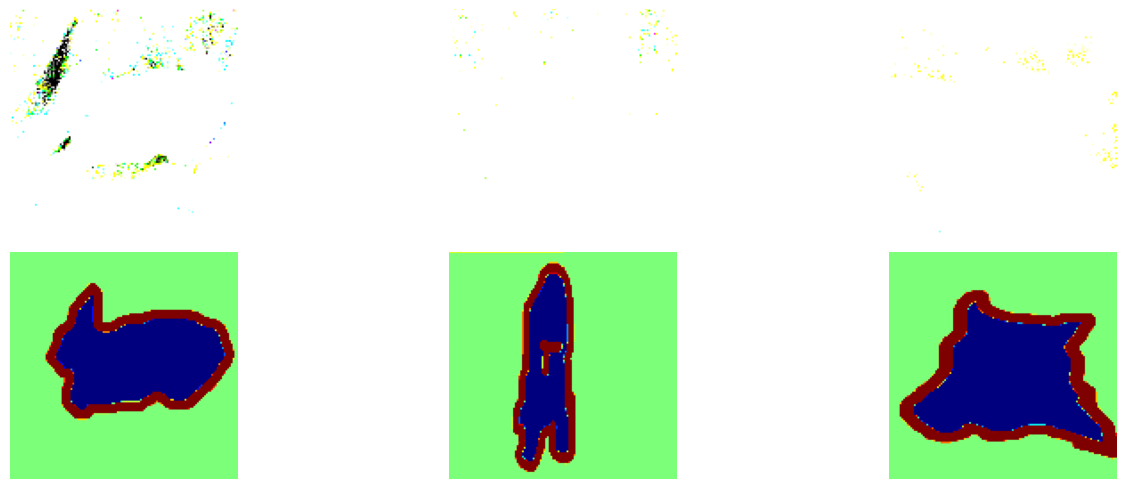

In [ ]:
# b) Create the segmentation mask
# Function to display samples with masks
def display_samples(dataset, num=3):
    plt.figure(figsize=(15, 5))
    for i, (input_image, input_mask) in enumerate(dataset.take(num)):
        img = input_image.numpy()
        img = np.clip(img, 0, 1)

        mask = tf.squeeze(input_mask).numpy()
        plt.subplot(2, num, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.subplot(2, num, i + 1 + num)
        plt.imshow(mask, cmap='jet')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

display_samples(train, num=3)
# Show some images from dataset and their segmented version

Leaving orginal code above to see picture difference for white space error

DEBUG img: (128, 128, 3) float32 0.0 0.79185045
DEBUG img: (128, 128, 3) float32 0.0 1.0
DEBUG img: (128, 128, 3) float32 0.0 0.9862422


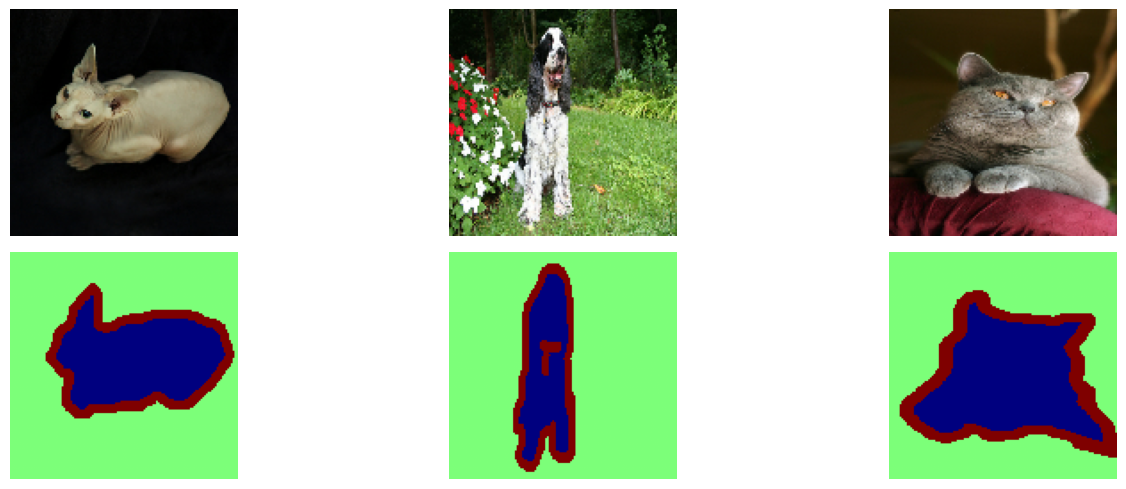

In [ ]:
def read_and_preprocess(data):
    input_image = data['image']
    input_mask = data['segmentation_mask']
    # Normalize if needed
    if input_image.dtype == tf.uint8:
        input_image = tf.cast(input_image, tf.float32) / 255.0
    input_image = tf.image.resize(input_image, (128, 128))
    input_mask = tf.image.resize(input_mask, (128, 128), method="nearest")
    input_mask -= 1
    return input_image, input_mask

train = dataset['train'].map(read_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test = dataset['test'].map(read_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

def display_samples(dataset, num=3):
    plt.figure(figsize=(15, 5))
    for i, (input_image, input_mask) in enumerate(dataset.take(num)):
        img = input_image.numpy()
        print("DEBUG img:", img.shape, img.dtype, np.min(img), np.max(img))
        img = np.clip(img, 0, 1)
        mask = tf.squeeze(input_mask).numpy()
        plt.subplot(2, num, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.subplot(2, num, i + 1 + num)
        plt.imshow(mask, cmap='jet')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

display_samples(train, num=3)

**Part 2- Annotation**

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

In [ ]:
# Install mrcnn
!pip install mrcnn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mrcnn: filename=mrcnn-0.2-py3-none-any.whl size=54908 sha256=81b700f3e01b584482d5199b3adf6db5d0dbad2381f5b77ba8dc3870a4e5e59e
  Stored in directory: /root/.cache/pip/wheels/b7/db/29/56f408f3de99a3a51d37bf2e9ac3b67fdafa32a9bf8054cc0a
Successfully built mrcnn


In [ ]:
# Get data from here https://github.com/experiencor/raccoon_dataset
!git clone https://github.com/experiencor/raccoon_dataset.git

Cloning into 'raccoon_dataset'...
remote: Enumerating objects: 646, done.
remote: Counting objects: 100% (646/646), done.
remote: Compressing objects: 100% (232/232), done.
remote: Total 646 (delta 413), reused 643 (delta 412), pack-reused 0 (from 0)
Receiving objects: 100% (646/646), 48.00 MiB | 16.50 MiB/s, done.
Resolving deltas: 100% (413/413), done.


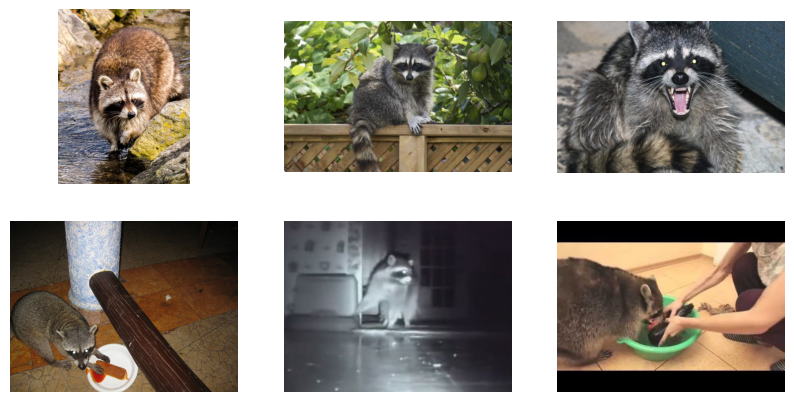

In [ ]:
# Get data
import os
from matplotlib import pyplot as plt
from PIL import Image

dataset_dir = './raccoon_dataset/images'
image_files = [f for f in os.listdir(dataset_dir) if f.endswith('.jpg')]
plt.figure(figsize=(10,5))
for i, file in enumerate(image_files[:6]):
    plt.subplot(2, 3, i + 1)
    img = Image.open(os.path.join(dataset_dir, file))
    plt.imshow(img)
    plt.axis('off')


plt.show()


# Plot some samples


In [ ]:
from os import listdir
from xml.etree import ElementTree
from numpy import zeros
from numpy import asarray
from mrcnn.utils import Dataset

# class that defines and loads the raccoon dataset
class RaccoonDataset(Dataset):
	# load the dataset definitions
	def load_dataset(self, dataset_dir, is_train=True):
		# define one class
		self.add_class("raccoon_dataset", 1, "raccoon")
		# define data locations
		images_dir = dataset_dir + '/images/'
		annotations_dir = dataset_dir + '/annotations/raccoon-'
		# find all images
		for filename in listdir(images_dir):
			# extract image id
			image_id = filename[8:-4]
			# skip bad images
			if image_id in ['00090']:
				continue
			# skip all images after 150 if we are building the train set
			if is_train and int(image_id) >= 150:
				continue
			# skip all images before 150 if we are building the test/val set
			if not is_train and int(image_id) < 150:
				continue
			img_path = images_dir + filename
			ann_path = annotations_dir + image_id + '.xml'
			# add to dataset
			self.add_image('dataset', image_id=image_id, path=img_path, annotation=ann_path)

	# extract bounding boxes from an annotation file
	def extract_boxes(self, filename):
		# load and parse the file
		tree = ElementTree.parse(filename)
		# get the root of the document
		root = tree.getroot()
		# extract each bounding box
		boxes = list()
		for box in root.findall('.//bndbox'):
			xmin = int(box.find('xmin').text)
			ymin = int(box.find('ymin').text)
			xmax = int(box.find('xmax').text)
			ymax = int(box.find('ymax').text)
			coors = [xmin, ymin, xmax, ymax]
			boxes.append(coors)
		# extract image dimensions
		width = int(root.find('.//size/width').text)
		height = int(root.find('.//size/height').text)
		return boxes, width, height

	# load the masks for an image
	def load_mask(self, image_id):
		# get details of image
		info = self.image_info[image_id]
		# define box file location
		path = info['annotation']
		# load XML
		#path = '/content/raccoon_dataset/annotations/raccoon-'+image_id   #Added for colab use
		boxes, w, h = self.extract_boxes(path)
		# create one array for all masks, each on a different channel
		masks = zeros([h, w, len(boxes)], dtype='uint8')
		# create masks
		class_ids = list()
		for i in range(len(boxes)):
			box = boxes[i]
			row_s, row_e = box[1], box[3]
			col_s, col_e = box[0], box[2]
			masks[row_s:row_e, col_s:col_e, i] = 1
			class_ids.append(self.class_names.index('raccoon'))
		return masks, asarray(class_ids, dtype='int32')

	# load an image reference
	def image_reference(self, image_id):
		info = self.image_info[image_id]
		return info['path']

# train set
train_set = RaccoonDataset()
train_set.load_dataset('raccoon_dataset', is_train=True)
train_set.prepare()
print('Train: %d' % len(train_set.image_ids))

# test/val set
test_set = RaccoonDataset()
test_set.load_dataset('raccoon_dataset', is_train=False)
test_set.prepare()
print('Test: %d' % len(test_set.image_ids))

Train: 149
Test: 51


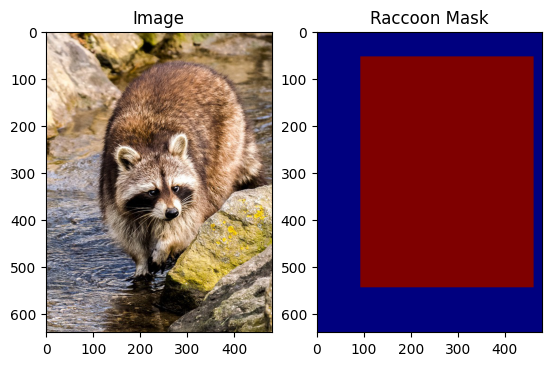

In [ ]:
# load an image
# Use the function above to create the image and its mask
rac_dataset = RaccoonDataset()
rac_dataset.load_dataset('raccoon_dataset', is_train=True)
rac_dataset.prepare()
image_id = rac_dataset.image_ids[0]
input_image = rac_dataset.load_image(image_id)
input_mask, class_ids = rac_dataset.load_mask(image_id)
plt.subplot(1,2,1)
plt.imshow(input_image)
plt.title('Image')
plt.subplot(1,2,2)
plt.imshow(input_mask[:,:,0], cmap='jet')
plt.title('Raccoon Mask')
plt.show()

**Part 3- YOLO**




You can see how YOLO has been improved in the last few versions on COCO: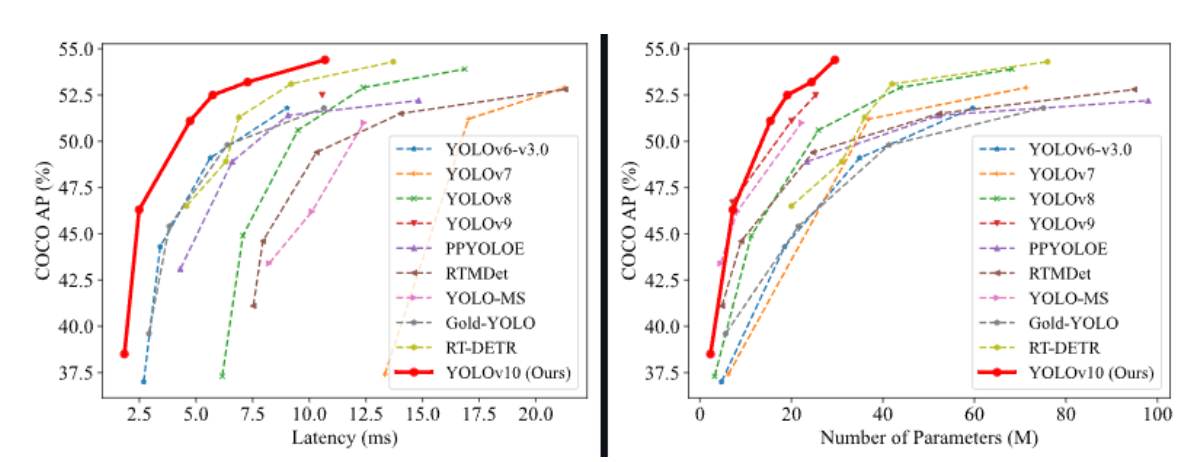

In [ ]:
# a- Create annotation
# You can upload the file using ![title](filename.jpeg)
# import image module

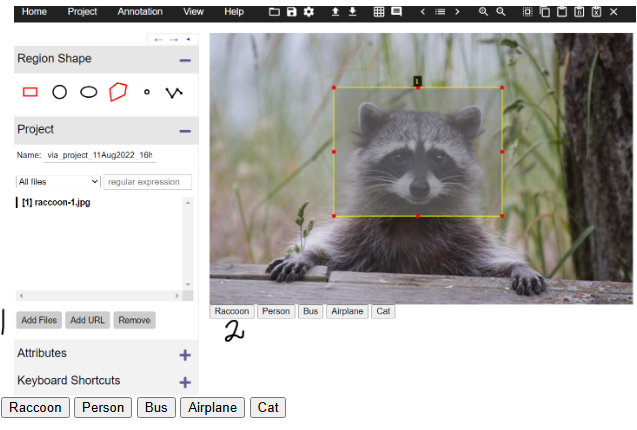![image.png]()

In [ ]:
#b- Download required tools
import os
HOME = os.getcwd()
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.5 MB/s eta 0:00:00


In [ ]:
#c- Test the model out of box
from ultralytics import YOLO
model = YOLO()
model.predict(source="https://ultralytics.com/images/bus.jpg", conf=0.25, save=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Download failure, retrying 1/3 https://ultralytics.com/images/bus.jpg... HTTP Error 403: Forbidden
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 73.7ms
Speed: 10.6ms preprocess, 73.7ms inference, 8.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

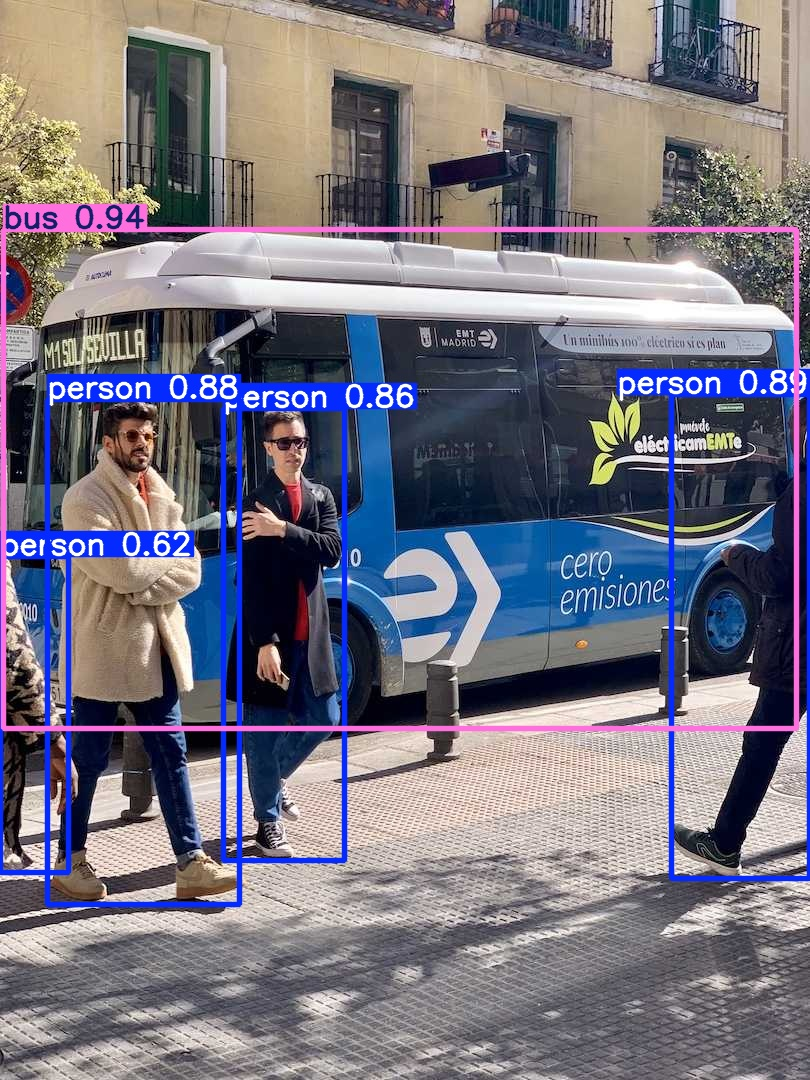

In [ ]:
from IPython.display import Image
Image(filename='runs/detect/predict/bus.jpg' )

In [ ]:
#d- Apply model
!yolo task=detect mode=train model=yolov8n.pt data=african-wildlife.yaml epochs=10 batch=32


Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

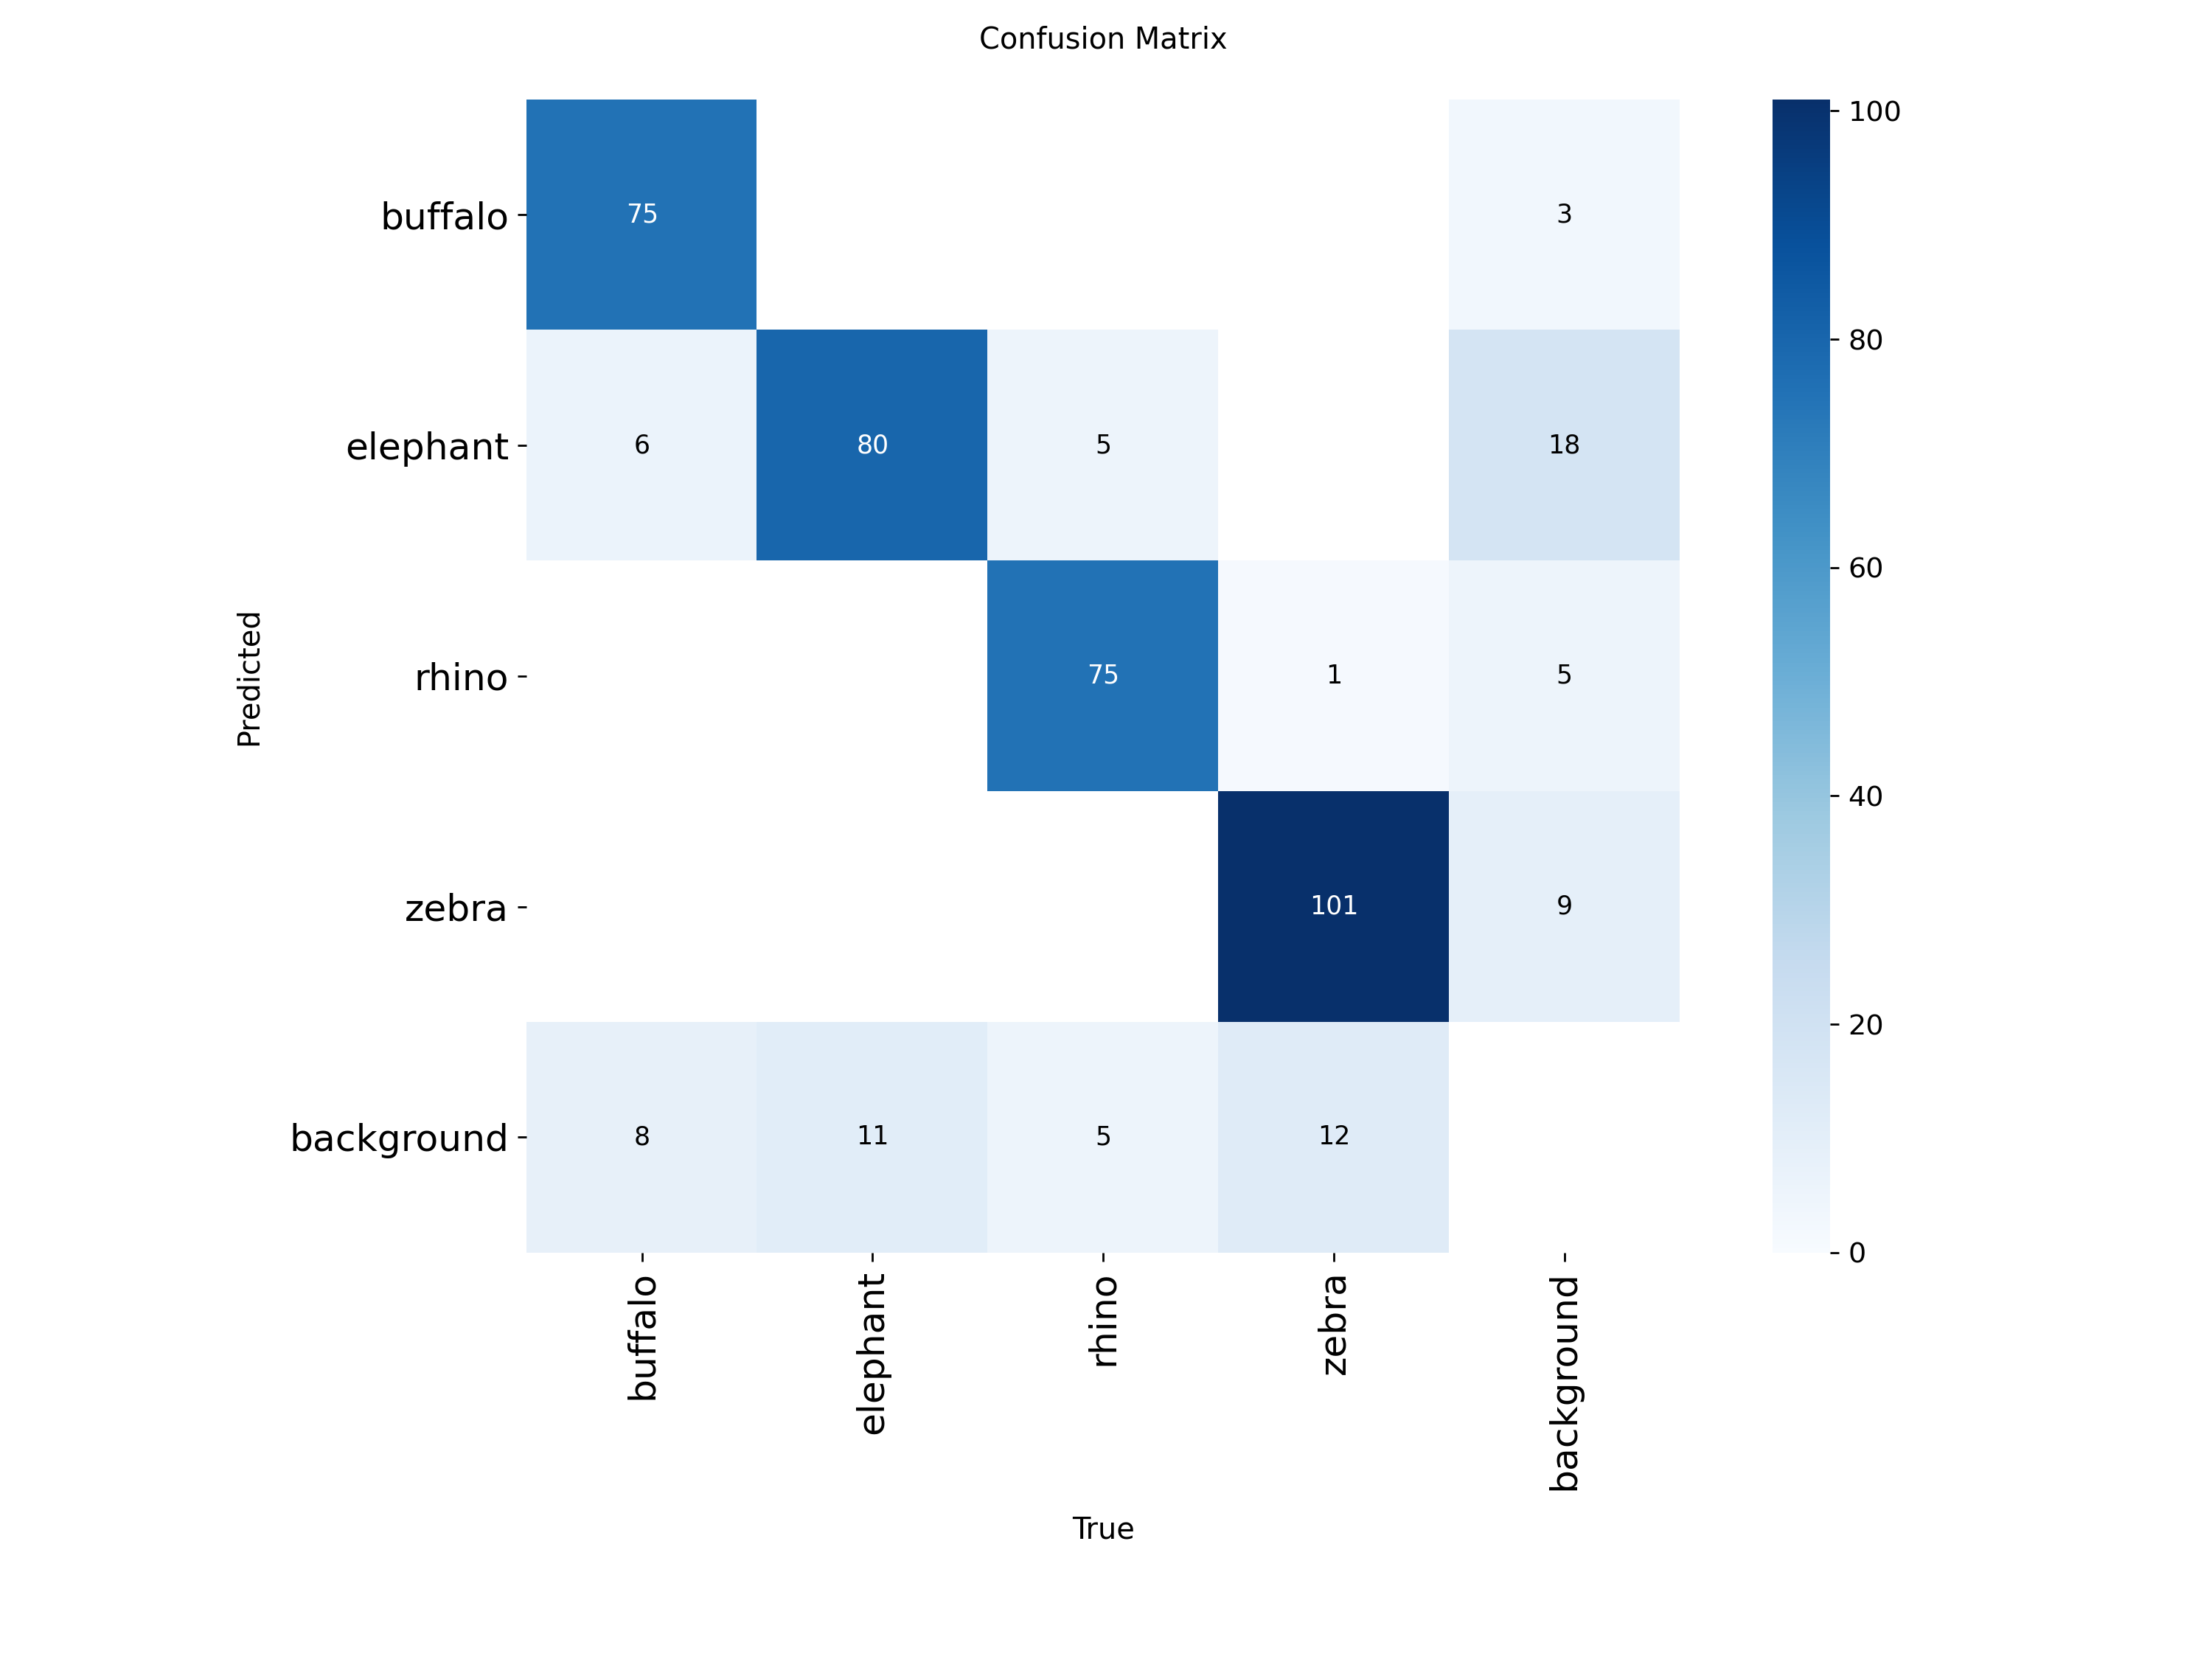

In [ ]:
#d- Fine-tune the model
#model fine tuned above
#show learning curve and matrix
from IPython.display import Image
Image(filename='runs/detect/train/confusion_matrix.png')  # confusion matrix

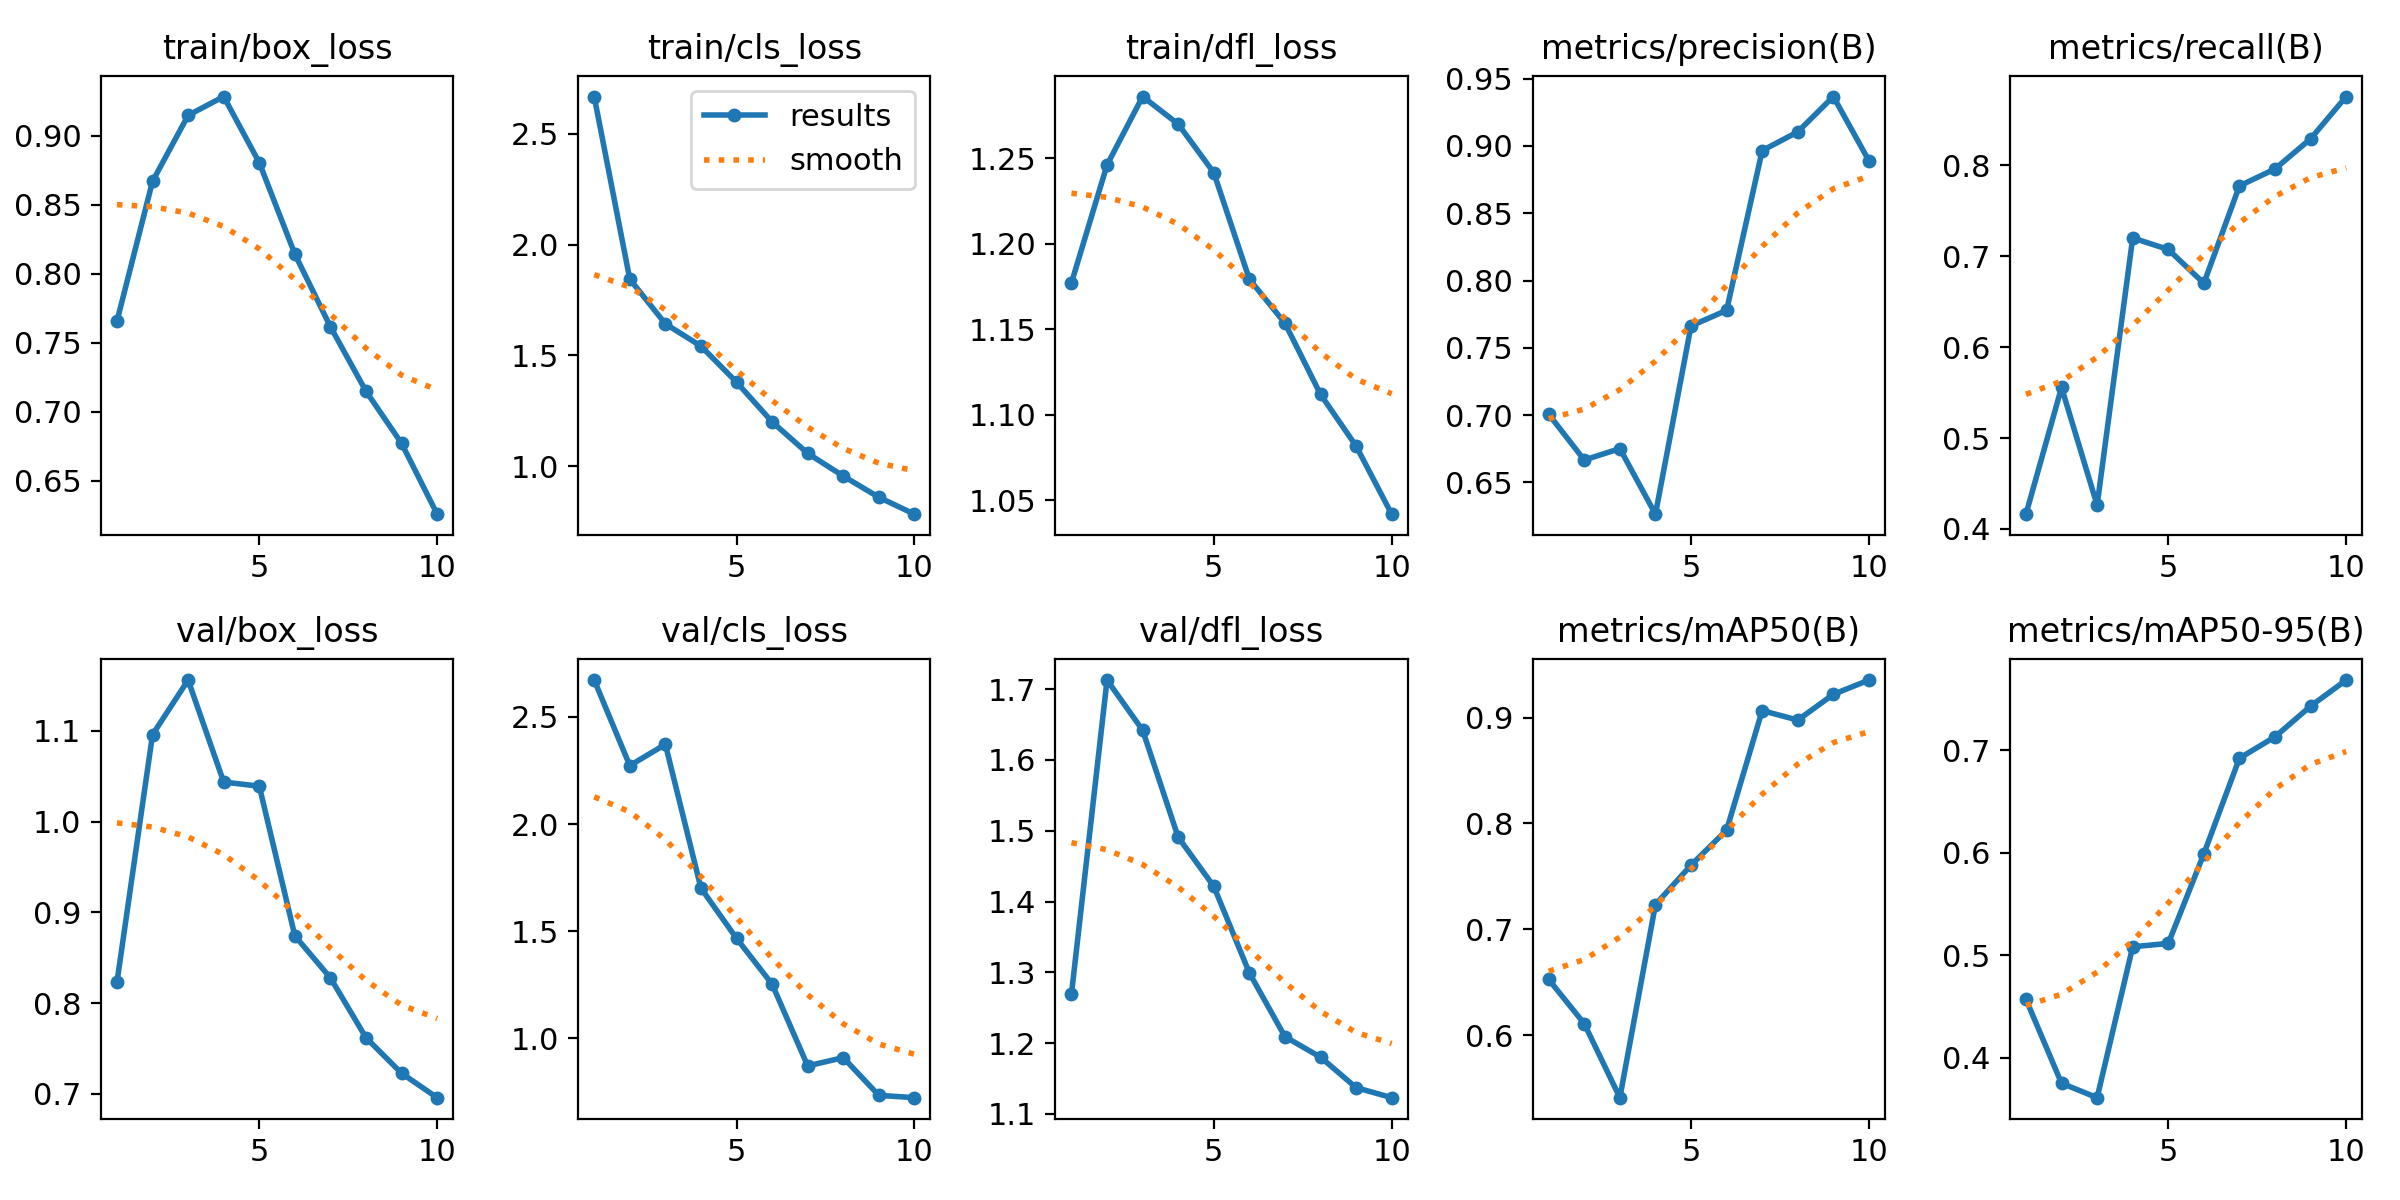

In [ ]:
Image(filename='runs/detect/train/results.png')  # learning curve

In [ ]:
# e- Explaining the learning curves and confusion matrix.


Box loss: Measures how well bounding box coordinates match ground truth.

Cls loss: Classification loss for predicted label vs actual.

Dfl loss: Distribution focal loss (objectness/centerness).

Train vs Val: Shows results on training and validation splits.

Box Loss (box_loss)
When I look at the box loss curve in my YOLO training results, I'm checking how well my model's predicted bounding boxes align with the actual object locations in the images. A steadily decreasing box loss over each epoch tells me that my model is learning to draw tighter, more accurate boxes around objects. If box loss stops improving or goes up, that's a red flag that my model isn't getting better at localization.

Classification Loss (cls_loss)
The classification loss shows me how well the model labels detected objects with the correct class. If the cls_loss curve is trending downward, it means my model is making fewer mistakes in identifying what each object is. A persistently high or flat cls_loss would signal that my model is struggling to distinguish between certain classes.

Distribution Focal Loss (dfl_loss)
Dfl loss reflects how confident and precise the model is about the center and boundaries of each detected object. When I see dfl_loss decreasing, I know the model is getting better at focusing on the right spots (object centers) and not being thrown off by ambiguous or difficult regions in the image. High dfl_loss could mean the model is still uncertain about object locations, especially in cluttered scenes.

Train vs Val Curves
I compare the loss curves for the training data (train) and the validation data (val) to see how well my model generalizes. If both sets of curves go down together and finish close to each other, that tells me my model isn't just memorizing the training examples—it's also performing well on new, unseen images. A big gap (with much lower train loss than val loss) means overfitting and I may need more data or better regularization.

Confusion Matrix
The confusion matrix lets me see exactly where my model is making correct predictions (shown by high diagonal values) and where it's making mistakes (off-diagonal values). I use it to spot which classes are often confused with each other; for example, if the model frequently mistakes one animal for another, or predicts background when there's actually an object present. This helps me target specific weaknesses in the model's classification performance.

#Conclusion

Through this project, I gained hands-on experience with the full object detection pipeline. I learned how proper data preprocessing, clear annotation, and effective fine-tuning can dramatically improve model results. By analyzing key metrics, box loss, classification loss, DFL loss, train/validation curves, and confusion matrices. I was able to evaluate whether my models were overfitting, generalizing, or confusing similar classes. The project reinforced the importance of iterative experimentation and thoughtful analysis when working with complex computer vision challenges. I now feel more comfortable applying and adapting YOLO and segmentation methods for a variety of real world tasks.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

.

In [ ]:
# End of Doc